# Round 008 — T1 ตัวกรองแนวโน้ม (Faber / TSMOM)

ตัวเลขทั้งหมดอ่านจาก `results.csv` ที่ `run.py` ของ round นี้เขียนไว้ · ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023 · ⚠️ survivorship: ราคาของหุ้นที่ออกจากตลาดไปแล้วหายบางส่วน → ผลอาจดูดีเกินจริง · held-out (ตั้งแต่ ก.ค. 2023) ไม่ถูกใช้

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_008/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r008_B_EW,0.183,0.614,0.681,0.032,0.122,-0.396,-0.384,False,False,0.000,0.000,261.819,0,1.075,1.093
1,r008_A_LOWACC_WCAP,0.956,0.614,0.681,0.158,0.122,-0.286,-0.384,True,True,0.676,0.015,53.472,0,0.828,1.093
2,r008_B_LOWACC_WCAP,0.647,0.614,0.681,0.112,0.122,-0.286,-0.384,False,False,0.378,0.002,54.319,0,0.883,1.093


ผู้เข้ารอบ (S1+S2+S3+S6): []


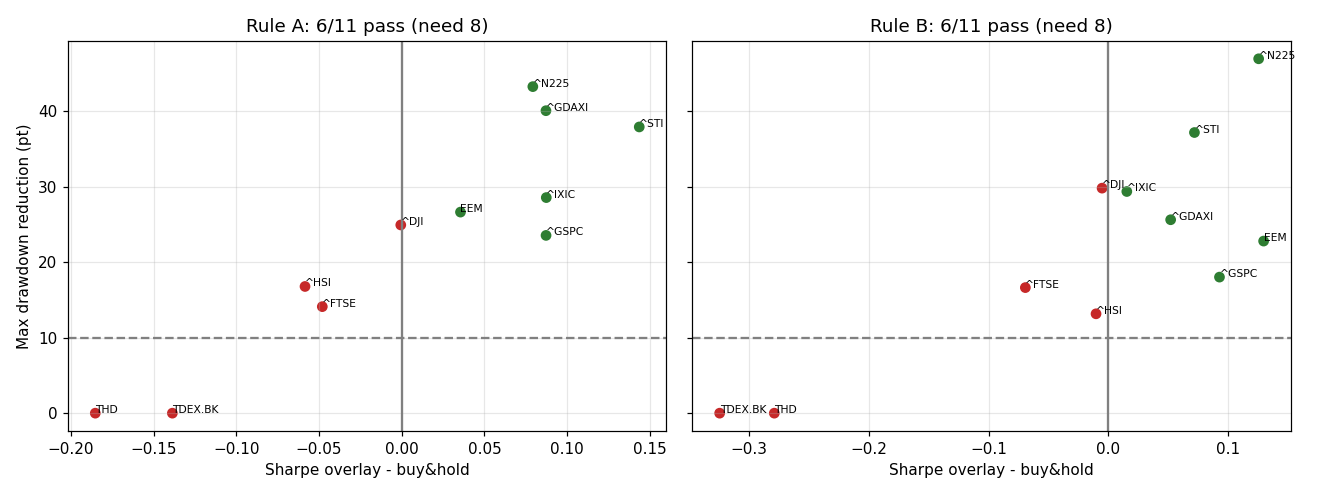

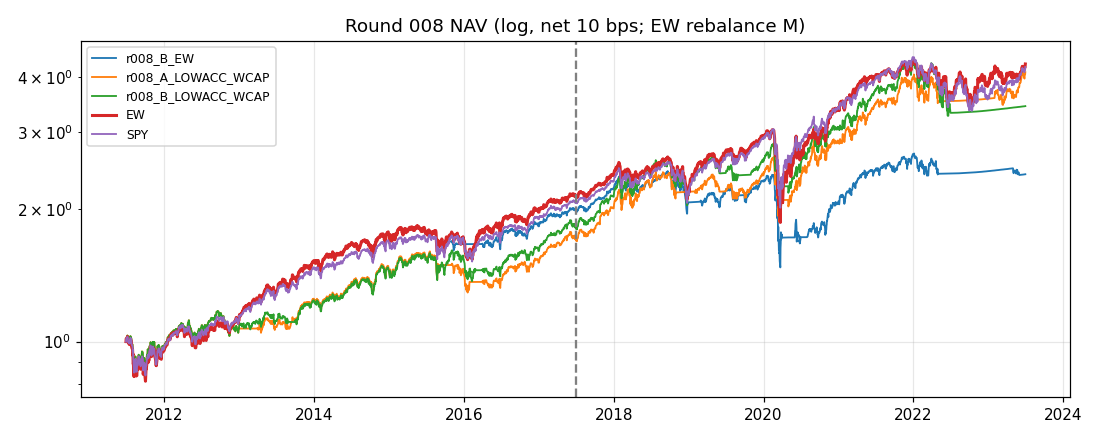

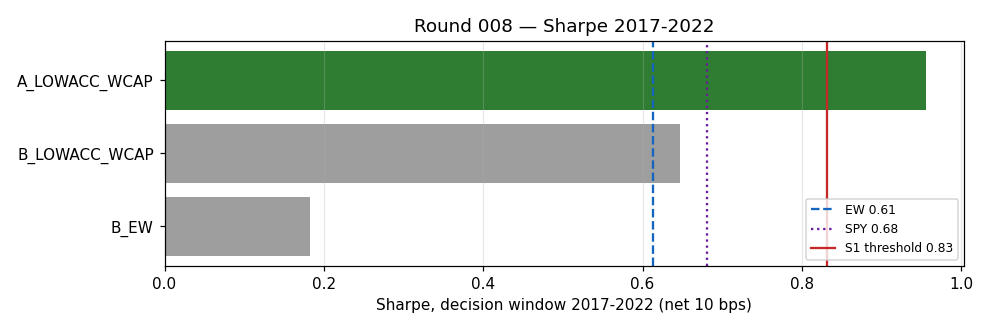

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_008_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_008/RESULTS.md").read_text()))

# Round 008 — EXPLORE2 T1: ตัวกรองแนวโน้มระดับตลาด — ป้าย "ลดความเสี่ยงได้จริง": **ไม่ได้** (ทั้งกฎ A และ B)

เกณฑ์ใน `PREREG_OVERLAY.md` (ล็อกก่อนรัน): ผ่านในตลาด = Sharpe สูงขึ้น **และ** max drawdown ลดลง ≥ 10 จุด; ได้ป้ายเมื่อผ่าน ≥ 8/11 ตลาด

| กฎ | ผ่าน | ป้าย |
|---|---|---|
| A (Faber SMA 10 เดือน) | 6/11 | ไม่ได้ |
| B (TSMOM 12 เดือน) | 6/11 | ไม่ได้ |

![index overlay](../../figures/round_008_index_overlay.png)

## ระดับดัชนี (ข้อมูลถึง 2023-06-30; เงินสดได้ ^IRX; ต้นทุน 10 bps ต่อการสลับ) — ไม่นับ trial
| market | rule | years | CAGR_overlay | CAGR_bh | CAGR_lost | Sharpe_overlay | Sharpe_bh | MaxDD_overlay | MaxDD_bh | DD_reduction_pt | time_in_cash_% | pass |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| ^GSPC | A | 53.500 | 0.079 | 0.075 | 0.004 | 0.360 | 0.273 | -0.332 | -0.568 | 23.539 | 28.594 | True |
| ^GSPC | B | 53.500 | 0.080 | 0.075 | 0.005 | 0.366 | 0.273 | -0.388 | -0.568 | 18.017 | 33.492 | True |
| ^DJI | A | 31.500 | 0.066 | 0.079 | -0.013 | 0.432 | 0.433 | -0.289 | -0.538 | 24.921 | 25.474 | False |
| ^DJI | B | 31.500 | 0.064 | 0.079 | -0.014 | 0.427 | 0.433 | -0.240 | -0.538 | 29.796 | 29.508 | False |
| ^IXIC | A | 52.400 | 0.103 | 0.099 | 0.004 | 0.434 | 0.347 | -0.494 | -0.779 | 28.547 | 30.000 | True |
| ^IXIC | B | 52.400 | 0.092 | 0.099 | -0.006 | 0.362 | 0.347 | -0.486 | -0.779 | 29.352 | 30.470 | True |
| ^N225 | A | 53.500 | 0.063 | 0.050 | 0.013 | 0.206 | 0.127 | -0.386 | -0.819 | 43.238 | 38.863 | True |
| ^N225 | B | 53.500 | 0.068 | 0.050 | 0.018 | 0.252 | 0.127 | -0.349 | -0.819 | 46.925 | 46.825 | True |
| ^FTSE | A | 39.500 | 0.045 | 0.053 | -0.008 | 0.143 | 0.191 | -0.385 | -0.526 | 14.106 | 33.118 | False |
| ^FTSE | B | 39.500 | 0.042 | 0.053 | -0.010 | 0.122 | 0.191 | -0.359 | -0.526 | 16.628 | 35.065 | False |
| ^GDAXI | A | 35.500 | 0.085 | 0.081 | 0.003 | 0.437 | 0.350 | -0.326 | -0.727 | 40.052 | 31.579 | True |
| ^GDAXI | B | 35.500 | 0.079 | 0.081 | -0.003 | 0.402 | 0.350 | -0.471 | -0.727 | 25.612 | 36.627 | True |
| ^HSI | A | 36.500 | 0.044 | 0.056 | -0.012 | 0.174 | 0.232 | -0.484 | -0.652 | 16.777 | 40.000 | False |
| ^HSI | B | 36.500 | 0.053 | 0.056 | -0.003 | 0.222 | 0.232 | -0.520 | -0.652 | 13.158 | 41.686 | False |
| ^STI | A | 35.500 | 0.059 | 0.039 | 0.020 | 0.296 | 0.153 | -0.298 | -0.677 | 37.899 | 39.952 | True |
| ^STI | B | 35.500 | 0.048 | 0.039 | 0.009 | 0.225 | 0.153 | -0.306 | -0.677 | 37.162 | 46.988 | True |
| EEM | A | 20.200 | 0.058 | 0.064 | -0.006 | 0.366 | 0.331 | -0.406 | -0.672 | 26.625 | 39.316 | True |
| EEM | B | 20.200 | 0.073 | 0.064 | 0.009 | 0.461 | 0.331 | -0.444 | -0.672 | 22.787 | 41.126 | True |
| TDEX.BK | A | 15.500 | 0.023 | 0.053 | -0.030 | 0.219 | 0.357 | -0.583 | -0.583 | -0.000 | 31.073 | False |
| TDEX.BK | B | 15.500 | -0.006 | 0.053 | -0.060 | 0.033 | 0.357 | -0.583 | -0.583 | -0.000 | 31.609 | False |
| THD | A | 15.200 | 0.003 | 0.043 | -0.040 | 0.088 | 0.274 | -0.642 | -0.642 | -0.000 | 36.782 | False |
| THD | B | 15.200 | -0.016 | 0.043 | -0.060 | -0.005 | 0.274 | -0.642 | -0.642 | -0.000 | 39.181 | False |

- ตลาดที่มีขาลงยาว (ญี่ปุ่นหลัง 1990, Nasdaq 2000–02, DAX, STI, EEM) ลด drawdown ได้ 18–47 จุดและ Sharpe ดีขึ้น
- ^DJI (เริ่ม 1992), ^FTSE, ^HSI: drawdown ลดแต่ Sharpe ไม่ดีขึ้น; SET proxy (เริ่ม 2008): drawdown ใหญ่สุดเกิด ต.ค. 2008 ระหว่างช่วงอุ่นเครื่องของกฎ (ตาม PREREG = ถือเต็ม) → ลดไม่ได้ และเสีย CAGR 3–6%/ปี
- CAGR ที่เสียไป: ดูคอลัมน์ `CAGR_lost` (ลบ = เสีย)

## ระดับพอร์ตของเรา (ช่วง design, S1–S7) — 3 trial ใหม่ (สะสม 118), ไม่มีผู้เข้ารอบ
| trial | Sharpe | CAGR | MaxDD | S1 | S2 | DSR | S6 | หมายเหตุ |
|---|---|---|---|---|---|---|---|---|
| `r008_B_EW` | 0.183 | 3.2% | -39.6% | False | 0% | 0.000 | False (ต่ำสุด 0) | time in cash 18.9% |
| `r008_A_LOWACC_WCAP` | 0.956 | 15.8% | -28.6% | True | 68% | 0.015 | False (ต่ำสุด 0) | time in cash 15.6% |
| `r008_B_LOWACC_WCAP` | 0.647 | 11.2% | -28.6% | False | 38% | 0.002 | False (ต่ำสุด 0) | time in cash 13.6% |

EW รายเดือน: Sharpe 0.614, CAGR 12.2%, MaxDD −38.4% · SPY Sharpe 0.681 · กฎ A บน EW = `r005_trend_EW` (Sharpe 0.369) ไม่นับซ้ำ
- กฎ A บน low accruals (cap-weight) ผ่าน S1 (Sharpe 0.956) แต่ตก S2 (68%), S3 (DSR 0.015) และ S6 (มีเดือนถือเงินสด 100% → 0 หุ้น ตามตัวอักษรของ S6)
- กฎ B บน EW แย่มากช่วง design: ออกหลังตลาดดิ่ง มี.ค. 2020 แล้วพลาดช่วงฟื้น และถือเงินสดเกือบทั้งปี 2022–23

## การตีความ
ตัวกรองแนวโน้มช่วยได้จริงในตลาดที่มีขาลงยาวและนาน แต่ไม่ช่วยในตลาดที่ crash สั้นแล้วฟื้นเร็ว — ไม่ถึงเกณฑ์ 70% ของตลาดที่ล็อกไว้
